In [63]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [64]:
load_dotenv()

True

In [65]:
model = ChatGroq(model="llama-3.3-70b-versatile")

In [66]:
# creating the schema foe model to give the structure output

class EvaluationSchema(BaseModel):
    score: int = Field(..., description="The score of the essay, on a scale of 1 to 10.", ge=0, le=10)
    feedback: str = Field(..., description="Detailed feedback on the essay, highlighting strengths and areas for improvement.")

In [67]:
structured_model=model.with_structured_output(EvaluationSchema)

In [68]:
essay="""Outer space exploration is one of the most exciting and important activities of the modern world. It helps humans understand the universe, discover new planets, and develop advanced technologies. In recent years, space exploration has grown rapidly due to the efforts of many countries and private companies. Nations such as the NASA, ISRO, and European Space Agency are making remarkable achievements in this field.

One of the major goals of current space exploration is the study of Mars. Scientists believe that Mars may have once supported life. Missions such as the Perseverance Rover sent by NASA are collecting soil and rock samples to search for signs of ancient microorganisms. At the same time, countries are planning future human missions to Mars. These projects may help humans live on other planets in the future.

Another important area of exploration is the Moon. Many countries are returning to lunar missions after several decades. India gained worldwide recognition with its Chandrayaan missions. Chandrayaan-3 successfully landed near the Moon’s south pole, making India one of the leading nations in lunar exploration. Scientists are especially interested in the Moon’s ice deposits because they could provide water and fuel for future space missions.

Private companies are also playing a major role in space exploration today. [SpaceX](https://www.spacex.com?utm_source=chatgpt.com) has developed reusable rockets, which reduce the cost of space travel. The company is also working on spacecraft designed for missions to Mars. Other companies are focusing on satellite communication, space tourism, and scientific research. These developments are making space exploration more accessible and innovative.

Space exploration also benefits life on Earth. Satellites help in weather forecasting, communication, navigation, disaster management, and environmental monitoring. Technologies developed for space missions are often used in medicine, transportation, and everyday electronics. Therefore, investment in space science contributes to human progress in many ways.

However, space exploration also faces challenges. It requires huge financial investments and involves serious risks to astronauts. Space debris and environmental concerns are becoming major issues as more satellites are launched into orbit. International cooperation is necessary to ensure peaceful and safe exploration of space.

In conclusion, current outer space exploration is opening new possibilities for humanity. It increases scientific knowledge, inspires innovation, and may one day allow humans to live beyond Earth. With continued research and cooperation, space exploration will remain a vital part of the future of civilization.
"""

In [69]:
prompt = f'Evaluate the following essay on outer space exploration. Provide a score from 1 to 10, where 10 is excellent and 1 is poor. Also, give detailed feedback on the strengths and areas for improvement in the essay.'

structured_model.invoke(prompt)

EvaluationSchema(score=8, feedback='The essay provides a well-structured and informative discussion on outer space exploration, highlighting its significance and potential benefits. The writer demonstrates a good understanding of the topic and provides relevant examples to support their arguments. However, there are some areas for improvement, such as providing more in-depth analysis and supporting evidence from credible sources. Additionally, the writer could benefit from using more nuanced and sophisticated language to convey their ideas. Overall, the essay is well-written and engaging, but could be further strengthened with more attention to detail and depth of analysis.')

In [70]:
class EssayState(TypedDict):
    essay: str
    analysis_feedback: str
    clarity_feedback: str
    language_feedback: str
    overall_feedback: str
    individual_score: Annotated[list[int], operator.add] #reducer function to store individual scores and calculate the average score
    avg_score: float
    

In [71]:
def evulate_language(state:EssayState):
    #evaluate the language of the essay and return the feedback and score
    
    prompt = f'Evaluate the language used in the following essay. Provide a score from 1 to 10, where 10 is excellent and 1 is poor. Also, give detailed feedback on the strengths and areas for improvement in the language of the essay.\n\nEssay:\n{state["essay"]}'
    output = structured_model.invoke(prompt)
    
    return {'language_feedback': output.feedback, 'individual_score': [output.score]}

In [72]:
def evulate_clarity(state:EssayState):
    #evaluate the clarity of the essay and return the feedback and score
    
    prompt = f'Evaluate the clarity of the following essay. Provide a score from 1 to 10, where 10 is excellent and 1 is poor. Also, give detailed feedback on the strengths and areas for improvement in the clarity of the essay.\n\nEssay:\n{state["essay"]}'
    output = structured_model.invoke(prompt)
    
    return {'clarity_feedback': output.feedback, 'individual_score': [output.score]}

In [73]:
def evulate_analysis(state:EssayState):
    #evaluate the analysis of the essay and return the feedback and score
    
    prompt = f'Evaluate the depth of analysis provided in the following essay. Provide a score from 1 to 10, where 10 is excellent and 1 is poor. Also, give detailed feedback on the strengths and areas for improvement in the analysis of the essay.\n\nEssay:\n{state["essay"]}'
    output = structured_model.invoke(prompt)
    
    return {'analysis_feedback': output.feedback, 'individual_score': [output.score]}

In [74]:
def final_evaluation(state:EssayState):
    # calculate the average score and provide overall feedback

    # compute avg_score safely from individual_score
    scores = state.get('individual_score', [])
    if scores:
        avg_score = sum(scores) / len(scores)
    else:
        avg_score = None

    # summary of the feedback (use N/A when avg_score is not available)
    avg_text = f"{avg_score:.2f}" if avg_score is not None else "N/A"
    prompt = (
        f"Based on the following feedback create a summarized feedback: The essay received an average score of {avg_text}. "
        f"Language feedback: {state.get('language_feedback', '')}. "
        f"Clarity feedback: {state.get('clarity_feedback', '')}. "
        f"Analysis feedback: {state.get('analysis_feedback', '')}."
    )
    overall_feedback = model.invoke(prompt)

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [75]:
# creating the graph,adding nodes an edges

graph=StateGraph(EssayState)

# Adding nodes to the graph
graph.add_node('evulate_language', evulate_language)
graph.add_node('evulate_clarity', evulate_clarity)
graph.add_node('evulate_analysis', evulate_analysis)

graph.add_node('final_evaluation', final_evaluation)
 

# Adding edges to the graph

graph.add_edge(START, 'evulate_language')
graph.add_edge(START, 'evulate_clarity')
graph.add_edge(START, 'evulate_analysis')

graph.add_edge('evulate_language', 'final_evaluation')
graph.add_edge('evulate_clarity', 'final_evaluation')       
graph.add_edge('evulate_analysis', 'final_evaluation')
graph.add_edge('final_evaluation', END)

#compling the graph

workflow = graph.compile()


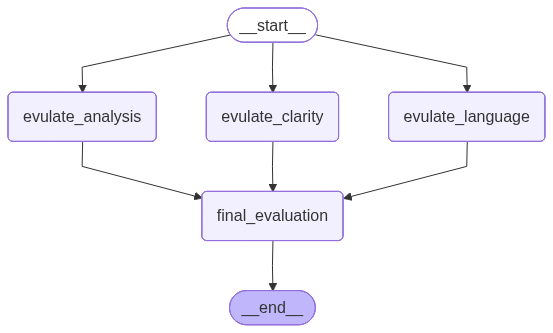

In [76]:
workflow

In [78]:
#executing the graph

initial_state={
    'essay': essay
    
}

final_state=workflow.invoke(initial_state)
final_state

{'essay': 'Outer space exploration is one of the most exciting and important activities of the modern world. It helps humans understand the universe, discover new planets, and develop advanced technologies. In recent years, space exploration has grown rapidly due to the efforts of many countries and private companies. Nations such as the NASA, ISRO, and European Space Agency are making remarkable achievements in this field.\n\nOne of the major goals of current space exploration is the study of Mars. Scientists believe that Mars may have once supported life. Missions such as the Perseverance Rover sent by NASA are collecting soil and rock samples to search for signs of ancient microorganisms. At the same time, countries are planning future human missions to Mars. These projects may help humans live on other planets in the future.\n\nAnother important area of exploration is the Moon. Many countries are returning to lunar missions after several decades. India gained worldwide recognition 